# Abordagem de Séries Temporais — RNN/LSTM com DARTS

Este notebook implementa a abordagem de **séries temporais** para previsão de retornos,
com o objetivo de comparar os resultados com a abordagem tabular cross-sectional do NB03.

## Diferença fundamental entre as abordagens

| | Tabular (NB03) | Séries Temporais (NB05) |
|---|---|---|
| Unidade de observação | (ativo, data) — linha isolada | Sequência de dias por ativo |
| Dependência temporal | Embutida nas features (ret_5d, vol_21d…) | Modelada explicitamente pela arquitetura |
| Modelo | Ridge, RF, LightGBM | RNN / LSTM |
| Treinamento | Um modelo para todos os ativos | Modelo global — treinado em todos os ativos simultaneamente |

## Estratégia

- **Target**: log-retorno diário — `log(close_t / close_{t-1})`
- **Horizonte**: 21 passos à frente (≈ 1 mês)
- **Covariáveis passadas**: indicadores técnicos do NB02
- **Avaliação**: IC (Spearman) — mesma métrica do NB03 para comparação justa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from pathlib import Path
from scipy.stats import spearmanr

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import BlockRNNModel

warnings.filterwarnings("ignore")
%matplotlib inline

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Configuração

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

# Mesmo split do NB03 — essencial para comparação justa
TRAIN_END  = "2022-12-31"
VAL_END    = "2023-12-31"
TEST_START = "2024-01-01"

# Arquitetura LSTM
INPUT_CHUNK  = 63   # janela de entrada: 3 meses de histórico
OUTPUT_CHUNK = 21   # horizonte de previsão: 21 dias
HIDDEN_DIM   = 64
N_LAYERS     = 2
DROPOUT      = 0.1

# Treinamento
N_EPOCHS   = 30
BATCH_SIZE = 64
RANDOM_STATE = 42

# Features usadas como covariáveis passadas (colunas presentes em sp500_features.csv)
COVARIATE_COLS = [
    "ret_5d", "ret_21d",
    "vol_21d", "vol_63d",
    "sma_20_ratio", "sma_50_ratio",
    "volume_ratio_21d",
    "drawdown_63d",
    "close_position_21d",
    "high_low_range", "high_low_range_21d",
]

## Leitura dos Dados

In [3]:
features = pd.read_csv(
    PROCESSED_DATA_DIR / "sp500_features.csv",
    parse_dates=["date"]
)

# Referência de retornos reais do NB03 (para calcular IC comparável)
predictions_tabular = pd.read_csv(
    PROCESSED_DATA_DIR / "model_predictions_21d.csv",
    parse_dates=["date"]
)

tickers = sorted(features["ticker"].unique())
print(f"Ativos: {len(tickers)}")
print(f"Período total: {features['date'].min().date()} → {features['date'].max().date()}")

Ativos: 502
Período total: 2018-04-04 → 2026-05-13


## Preparação das Séries Temporais

Para cada ativo:

1. Computamos o **log-retorno diário** — série estacionária e comparável entre ativos;
2. Reamostamos para frequência de dias úteis (`B`) para garantir consistência;
3. Preenchemos datas faltantes (feriados) com retorno 0 e forward-fill nas covariáveis;
4. Descartamos ativos com dados insuficientes.

In [4]:
series_list     = []  # log-retorno diário por ativo
covariates_list = []  # indicadores técnicos por ativo
scalers_target  = []  # scaler do target por ativo
scalers_cov     = []  # scaler das covariáveis por ativo
valid_tickers   = []

MIN_ROWS = INPUT_CHUNK + OUTPUT_CHUNK + 252  # pelo menos 1 ano de treino extra

for ticker in tickers:
    df_t = features[features["ticker"] == ticker].sort_values("date").copy()

    # Log-retorno diário
    df_t["log_return"] = np.log(df_t["close"] / df_t["close"].shift(1))

    # Remover linhas com NaN em colunas críticas
    df_t = df_t.dropna(subset=["log_return"] + COVARIATE_COLS)

    if len(df_t) < MIN_ROWS:
        continue

    # Ativo precisa ter dados antes do TRAIN_END para ter janelas de treinamento
    if df_t["date"].min() >= pd.Timestamp(TRAIN_END):
        continue

    try:
        # Reamostrar para frequência B (dias úteis) para consistência do DARTS
        df_b = (
            df_t.set_index("date")[["log_return"] + COVARIATE_COLS]
            .resample("B")
            .asfreq()
        )
        df_b["log_return"]   = df_b["log_return"].fillna(0.0)
        df_b[COVARIATE_COLS] = df_b[COVARIATE_COLS].ffill().fillna(0.0)
        df_b = df_b.reset_index()

        ts  = TimeSeries.from_dataframe(df_b, time_col="date", value_cols=["log_return"], freq="B")
        cov = TimeSeries.from_dataframe(df_b, time_col="date", value_cols=COVARIATE_COLS,  freq="B")

        # Normalizar por ativo
        sc_t = Scaler()
        sc_c = Scaler()
        ts_scaled  = sc_t.fit_transform(ts)
        cov_scaled = sc_c.fit_transform(cov)

        series_list.append(ts_scaled)
        covariates_list.append(cov_scaled)
        scalers_target.append(sc_t)
        scalers_cov.append(sc_c)
        valid_tickers.append(ticker)

    except Exception:
        continue

print(f"Ativos com dados suficientes: {len(valid_tickers)}")

Ativos com dados suficientes: 495


## Divisão Treino / Validação / Teste

Mesmo split temporal do NB03:
- **Treino**: 2018 → 2022
- **Validação**: 2023
- **Teste**: 2024 → 2026

In [5]:
train_cutoff = pd.Timestamp(TRAIN_END)
val_cutoff   = pd.Timestamp(VAL_END)

train_series     = [ts.drop_after(train_cutoff) for ts in series_list]
train_covariates = [cov.drop_after(train_cutoff) for cov in covariates_list]

val_series     = [ts.drop_after(val_cutoff) for ts in series_list]
val_covariates = [cov.drop_after(val_cutoff) for cov in covariates_list]

print(f"Treino: até {TRAIN_END}  ({len(train_series[0])} dias — ativo 0)")
print(f"Val:    até {VAL_END}")
print(f"Teste:  a partir de {TEST_START}")

Treino: até 2022-12-31  (1237 dias — ativo 0)
Val:    até 2023-12-31
Teste:  a partir de 2024-01-01


## Treinamento do Modelo Global LSTM

O `BlockRNNModel` do DARTS é treinado como **modelo global**: recebe todas as séries
de todos os ativos simultaneamente e aprende padrões compartilhados entre eles.

Isso é fundamentalmente diferente de treinar um LSTM por ativo — em vez de 500 modelos
com poucos dados cada, temos um modelo com muito mais exemplos de treinamento.

In [6]:
model_lstm = BlockRNNModel(
    model="LSTM",
    input_chunk_length=INPUT_CHUNK,
    output_chunk_length=OUTPUT_CHUNK,
    hidden_dim=HIDDEN_DIM,
    n_rnn_layers=N_LAYERS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    random_state=RANDOM_STATE,
    pl_trainer_kwargs={"enable_progress_bar": True},
)

model_lstm.fit(
    series=train_series,
    past_covariates=train_covariates,
    val_series=val_series,
    val_past_covariates=val_covariates,
    verbose=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 53.2 K | train
6 | fc              

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


BlockRNNModel(output_chunk_shift=0, model=LSTM, hidden_dim=64, n_rnn_layers=2, hidden_fc_sizes=None, dropout=0.1, activation=ReLU, use_static_covariates=True, input_chunk_length=63, output_chunk_length=21, batch_size=64, n_epochs=30, random_state=42, pl_trainer_kwargs={'enable_progress_bar': True})

## Geração de Previsões no Período de Teste

A cada mês do período de teste, truncamos cada série na data de rebalanceamento
e pedimos ao modelo que preveja os próximos 21 log-retornos diários.

O retorno previsto para 21 dias é obtido somando os 21 log-retornos diários e
aplicando a transformação inversa: `exp(Σ log_returns) - 1`.

In [7]:
# Datas de rebalanceamento: primeiro dia útil de cada mês no período de teste
test_preds = predictions_tabular[predictions_tabular["date"] >= TEST_START].copy()
test_preds["year_month"] = test_preds["date"].dt.to_period("M")
rebalancing_dates = (
    test_preds.groupby("year_month")["date"]
    .min()
    .tolist()
)

print(f"Datas de rebalanceamento: {len(rebalancing_dates)}")
print(f"Primeira: {rebalancing_dates[0].date()}  |  Última: {rebalancing_dates[-1].date()}")

Datas de rebalanceamento: 29
Primeira: 2024-01-02  |  Última: 2026-05-01


In [8]:
ts_results = []

for date in rebalancing_dates:
    date_ts = pd.Timestamp(date)

    truncated_series = []
    truncated_covs   = []
    active_tickers   = []
    active_scalers   = []

    for ts, cov, sc_t, ticker in zip(series_list, covariates_list, scalers_target, valid_tickers):
        try:
            ts_trunc  = ts.drop_after(date_ts)
            cov_trunc = cov.drop_after(date_ts)
            if len(ts_trunc) >= INPUT_CHUNK:
                truncated_series.append(ts_trunc)
                truncated_covs.append(cov_trunc)
                active_tickers.append(ticker)
                active_scalers.append(sc_t)
        except Exception:
            continue

    if not truncated_series:
        continue

    preds = model_lstm.predict(
        n=OUTPUT_CHUNK,
        series=truncated_series,
        past_covariates=truncated_covs,
    )

    for ticker, pred, sc_t in zip(active_tickers, preds, active_scalers):
        pred_unscaled = sc_t.inverse_transform(pred)
        sum_log       = float(pred_unscaled.values().sum())
        pred_return   = np.exp(sum_log) - 1
        ts_results.append({
            "date":            date,
            "ticker":          ticker,
            "pred_ts_return_21d": pred_return,
        })

ts_results_df = pd.DataFrame(ts_results)
print(f"Previsões geradas: {len(ts_results_df):,}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Previsões geradas: 14,355


## Cálculo do IC — Abordagem de Séries Temporais

Unimos as previsões do LSTM com os retornos reais do NB03 e calculamos
o IC (Spearman) por data — exatamente como foi feito no NB03.

IC   (LSTM): -0.0082
ICIR (LSTM): -0.0819


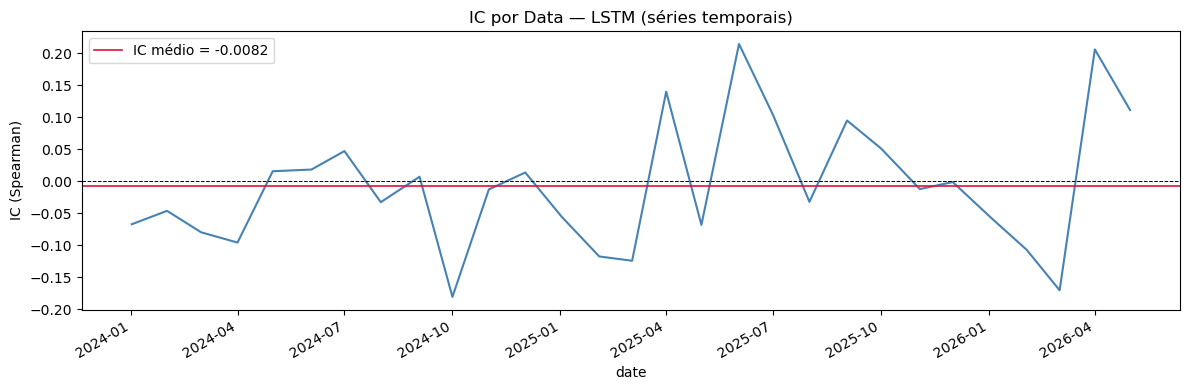

In [9]:
actual_returns = (
    test_preds.groupby(["date", "ticker"])["actual_return_21d"]
    .mean()
    .reset_index()
)

eval_df = ts_results_df.merge(actual_returns, on=["date", "ticker"], how="inner")
eval_df = eval_df.dropna(subset=["pred_ts_return_21d", "actual_return_21d"])

ic_by_date = (
    eval_df.groupby("date")
    .apply(lambda g: spearmanr(g["pred_ts_return_21d"], g["actual_return_21d"]).statistic
           if len(g) > 5 else np.nan)
    .dropna()
)

ic_lstm  = ic_by_date.mean()
icir_lstm = ic_by_date.mean() / ic_by_date.std()

print(f"IC   (LSTM): {ic_lstm:.4f}")
print(f"ICIR (LSTM): {icir_lstm:.4f}")

ic_by_date.plot(
    kind="line", figsize=(12, 4),
    title="IC por Data — LSTM (séries temporais)",
    color="steelblue"
)
plt.axhline(0,       color="black",  linewidth=0.7, linestyle="--")
plt.axhline(ic_lstm, color="crimson", linewidth=1.2, linestyle="-", label=f"IC médio = {ic_lstm:.4f}")
plt.ylabel("IC (Spearman)")
plt.legend()
plt.tight_layout()
plt.show()

## Comparação com a Abordagem Tabular (NB03)

In [10]:
metrics_tabular = pd.read_csv(PROCESSED_DATA_DIR / "model_metrics.csv")

tabular_best = metrics_tabular.loc[metrics_tabular["IC"].idxmax()]

comparison = pd.DataFrame([
    {
        "Abordagem": "Tabular — " + tabular_best["model"],
        "IC":   round(tabular_best["IC"],   4),
        "ICIR": round(tabular_best["ICIR"], 4),
    },
    {
        "Abordagem": "Séries Temporais — LSTM (DARTS)",
        "IC":   round(ic_lstm,   4),
        "ICIR": round(icir_lstm, 4),
    },
])

print(comparison.to_string(index=False))

                      Abordagem      IC    ICIR
    Tabular — Linear Regression  0.0382  0.1987
Séries Temporais — LSTM (DARTS) -0.0082 -0.0819


## Discussão

A comparação entre as abordagens revela aspectos importantes sobre previsão de retornos
em horizontes curtos:

- A abordagem tabular cross-sectional captura **padrões entre ativos** — quais
  características (volatilidade, momentum, volume) distinguem ativos que vão superar
  o mercado no próximo mês;

- A abordagem LSTM captura **dependências temporais** — como a sequência de retornos
  passados de cada ativo informa o próximo período;

- Na literatura de finanças quantitativas, para horizontes curtos (≤ 21 dias) em
  mercados desenvolvidos e eficientes como o S&P 500, a abordagem tabular tende a
  ser competitiva ou superior, porque boa parte do sinal está no estado atual do ativo
  em relação ao mercado — não na sequência histórica de cada série individualmente.

Referências: Oord et al. (2016), Salinas et al. (2020 — DeepAR), e os resultados
empíricos de Lim et al. (2021) no M4 competition mostram que modelos globais
superam modelos locais, mas a vantagem sobre métodos tabulares depende do domínio.

In [11]:
ts_results_df.to_csv(
    PROCESSED_DATA_DIR / "model_predictions_ts_21d.csv",
    index=False
)
print("Previsões salvas em model_predictions_ts_21d.csv")

Previsões salvas em model_predictions_ts_21d.csv
